## “Which vendors are most profitable, least profitable, and how do pricing and purchasing behaviors influence vendor performance?”

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

vendor_year = pd.read_csv("../data_processed/vendor_year_metrics.csv")
vendor_year.head()


,VendorNumber,VendorName,Year,PurchaseQty,PurchaseDollars,AvgPurchasePrice,SalesQty,SalesDollars,AvgSalesPrice,Profit,MarginPct
0,2.0,"IRA GOLDMAN AND WILLIAMS, LLP",2024,328.0,5630.88,17.167317,42.0,1265.58,30.132857,-4365.30,-3.449249
1,54.0,AAPER ALCOHOL & CHEMICAL CO,2024,1.0,105.07,105.070000,NaN,0.00,NaN,-105.07,NaN
2,60.0,ADAMBA IMPORTS INTL INC,2024,4429.0,71840.44,16.220465,3978.0,67576.22,16.987486,-4264.22,-0.063102
3,60.0,ADAMBA IMPORTS INTL INC,2025,303.0,4929.81,16.270000,NaN,0.00,NaN,-4929.81,NaN
4,105.0,ALTAMAR BRANDS LLC,2024,314.0,11138.18,35.471911,325.0,15748.75,48.457692,4610.57,0.292758


In [2]:
vendor_year.shape
vendor_year.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   VendorNumber      247 non-null    float64
 1   VendorName        247 non-null    object 
 2   Year              247 non-null    int64  
 3   PurchaseQty       244 non-null    float64
 4   PurchaseDollars   247 non-null    float64
 5   AvgPurchasePrice  244 non-null    float64
 6   SalesQty          136 non-null    float64
 7   SalesDollars      247 non-null    float64
 8   AvgSalesPrice     136 non-null    float64
 9   Profit            247 non-null    float64
 10  MarginPct         136 non-null    float64
dtypes: float64(9), int64(1), object(1)
memory usage: 21.4+ KB


In [6]:
vendor_year.isna().sum()


VendorNumber          0
VendorName            0
Year                  0
PurchaseQty           0
PurchaseDollars       0
AvgPurchasePrice      3
SalesQty              0
SalesDollars          0
AvgSalesPrice       111
Profit                0
MarginPct           111
dtype: int64

## 1️⃣ PurchaseQty, SalesQty → fill with 0
Because missing quantity means no activity occurred, not missing data. Zero is the true business value.

## Bullet Points to Add in Markdown
 Why AvgPurchasePrice / AvgSalesPrice remain NaN

Average price is only meaningful when units were actually purchased or sold.

If quantity = 0, the vendor had no activity, so the average price is undefined, not zero.

Filling with 0 incorrectly implies products were “free,” which misrepresents the data.

Leaving NaN preserves the true business meaning and avoids misleading KPIs.

## Why MarginPct stays NaN when Sales = 0

Margin = Profit ÷ SalesDollars → cannot be computed when sales = 0.

A vendor with zero sales cannot have a valid margin percentage.

Filling with 0 would imply a real “0% margin,” which is not true — the metric simply doesn’t apply.

Keeping NaN ensures downstream dashboards do not misinterpret vendor performance.

## Business meaning of vendors with purchases but no sales

Represents new vendors whose products have not launched or sold yet.

Could indicate slow-moving, poor-performing, or mismatched products.

May reflect overstock, dead inventory risk, or incorrect purchasing decisions.

Important signal for operational teams to review purchasing strategy and product performance.

In [7]:
# Fill missing quantities with 0 (no activity = 0)
vendor_year['PurchaseQty'] = vendor_year['PurchaseQty'].fillna(0)
vendor_year['SalesQty'] = vendor_year['SalesQty'].fillna(0)

# AvgPurchasePrice and AvgSalesPrice: leave as NaN (these metrics don't exist when qty=0)
# MarginPct: leave NaN if SalesDollars=0

# Profit is already safe because SalesDollars and PurchaseDollars are filled with 0


In [4]:
vendor_year.describe()


,VendorNumber,Year,PurchaseQty,PurchaseDollars,AvgPurchasePrice,SalesQty,SalesDollars,AvgSalesPrice,Profit,MarginPct
count,247.000000,247.000000,2.440000e+02,2.470000e+02,244.000000,1.360000e+02,2.470000e+02,136.000000,2.470000e+02,136.000000
mean,23076.376518,2024.441296,1.501866e+05,1.429115e+06,12.855549,2.651950e+05,2.027246e+06,18.106247,5.981309e+05,-6.002889
std,38517.428244,0.497550,5.162709e+05,4.938647e+06,9.548108,6.850956e+05,7.167264e+06,11.633632,3.746476e+06,47.357839
min,2.000000,2024.000000,1.000000e+00,0.000000e+00,3.475266,1.000000e+00,0.000000e+00,4.665419,-2.614048e+07,-476.057270
25%,2558.000000,2024.000000,3.355000e+02,4.774000e+03,8.042698,1.262500e+03,0.000000e+00,11.849124,-6.575145e+03,0.195786
50%,7153.000000,2024.000000,4.147000e+03,4.254434e+04,10.420588,9.557000e+03,1.616920e+03,15.647670,-3.542000e+01,0.295595
75%,11949.000000,2025.000000,3.370150e+04,3.140488e+05,14.727744,1.890598e+05,2.036093e+05,19.890305,4.455069e+04,0.365048
max,201359.000000,2025.000000,5.329972e+06,4.973333e+07,105.070000,5.422703e+06,6.874242e+07,111.268719,4.095218e+07,1.000000


In [8]:
print("Shape:", vendor_year.shape)

print("\nData Types:")
print(vendor_year.dtypes)

print("\nMissing Values:")
print(vendor_year.isna().sum())


Shape: (247, 11)

Data Types:
VendorNumber        float64
VendorName           object
Year                  int64
PurchaseQty         float64
PurchaseDollars     float64
AvgPurchasePrice    float64
SalesQty            float64
SalesDollars        float64
AvgSalesPrice       float64
Profit              float64
MarginPct           float64
dtype: object

Missing Values:
VendorNumber          0
VendorName            0
Year                  0
PurchaseQty           0
PurchaseDollars       0
AvgPurchasePrice      3
SalesQty              0
SalesDollars          0
AvgSalesPrice       111
Profit                0
MarginPct           111
dtype: int64


In [9]:
vendor_year.describe(include='all')


,VendorNumber,VendorName,Year,PurchaseQty,PurchaseDollars,AvgPurchasePrice,SalesQty,SalesDollars,AvgSalesPrice,Profit,MarginPct
count,247.000000,247,247.000000,2.470000e+02,2.470000e+02,244.000000,2.470000e+02,2.470000e+02,136.000000,2.470000e+02,136.000000
unique,NaN,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,MARTIGNETTI COMPANIES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,23076.376518,NaN,2024.441296,1.483624e+05,1.429115e+06,12.855549,1.460183e+05,2.027246e+06,18.106247,5.981309e+05,-6.002889
std,38517.428244,NaN,0.497550,5.133779e+05,4.938647e+06,9.548108,5.244484e+05,7.167264e+06,11.633632,3.746476e+06,47.357839
min,2.000000,NaN,2024.000000,0.000000e+00,0.000000e+00,3.475266,0.000000e+00,0.000000e+00,4.665419,-2.614048e+07,-476.057270
25%,2558.000000,NaN,2024.000000,3.100000e+02,4.774000e+03,8.042698,0.000000e+00,0.000000e+00,11.849124,-6.575145e+03,0.195786
50%,7153.000000,NaN,2024.000000,3.535000e+03,4.254434e+04,10.420588,8.200000e+01,1.616920e+03,15.647670,-3.542000e+01,0.295595
75%,11949.000000,NaN,2025.000000,3.192100e+04,3.140488e+05,14.727744,1.403150e+04,2.036093e+05,19.890305,4.455069e+04,0.365048


## Key Business Metrics

In [10]:
total_vendors = vendor_year['VendorNumber'].nunique()
total_purchase = vendor_year['PurchaseDollars'].sum()
total_sales = vendor_year['SalesDollars'].sum()
total_profit = vendor_year['Profit'].sum()
overall_margin = total_profit / total_sales

print("Unique Vendors:", total_vendors)
print("Total Purchase Dollars:", total_purchase)
print("Total Sales Dollars:", total_sales)
print("Total Profit:", total_profit)
print("Overall Margin:", overall_margin)


Unique Vendors: 129
Total Purchase Dollars: 352991431.43000007
Total Sales Dollars: 500729754.14
Total Profit: 147738322.70999998
Overall Margin: 0.29504602330600377


## Vendor Activity Summary Table

In [11]:
activity = vendor_year.assign(
    Purchased = vendor_year['PurchaseQty'] > 0,
    Sold = vendor_year['SalesQty'] > 0
)[['VendorName', 'Purchased', 'Sold']]

activity.head()


,VendorName,Purchased,Sold
0,"IRA GOLDMAN AND WILLIAMS, LLP",True,True
1,AAPER ALCOHOL & CHEMICAL CO,True,False
2,ADAMBA IMPORTS INTL INC,True,True
3,ADAMBA IMPORTS INTL INC,True,False
4,ALTAMAR BRANDS LLC,True,True


## Profit Distribution Analysis

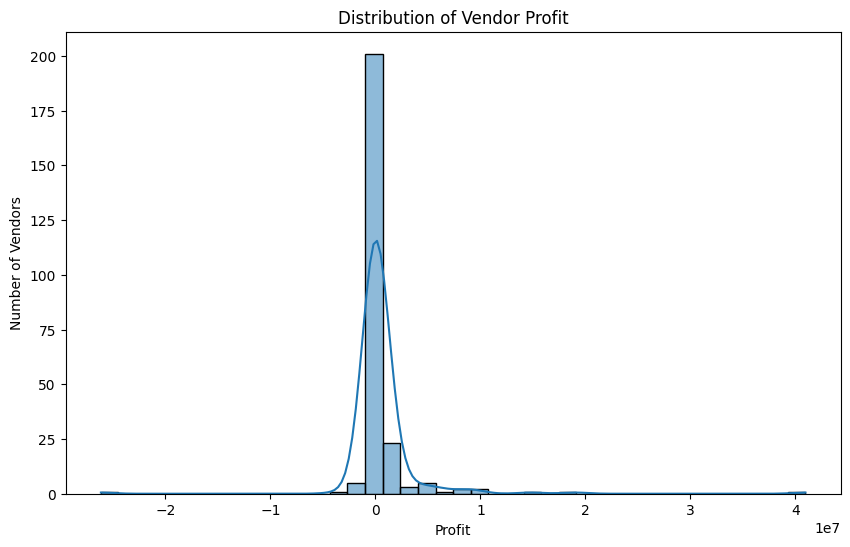

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(vendor_year['Profit'], bins=40, kde=True)
plt.title("Distribution of Vendor Profit")
plt.xlabel("Profit")
plt.ylabel("Number of Vendors")
plt.show()


## Profit Boxplot

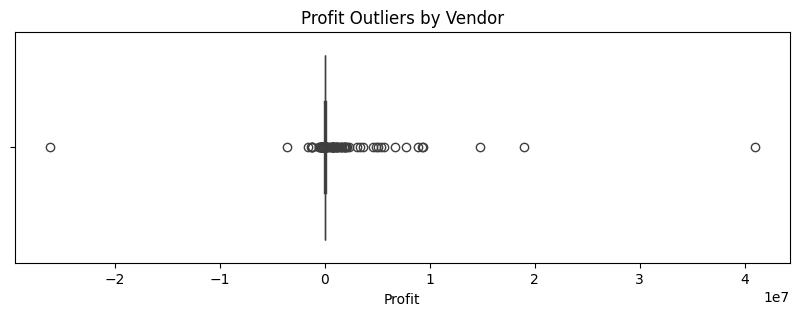

In [13]:
plt.figure(figsize=(10,3))
sns.boxplot(x=vendor_year['Profit'])
plt.title("Profit Outliers by Vendor")
plt.show()


## Insights

Vendor profit is highly right-skewed, meaning a small number of vendors contribute most of the company’s profit.

Most vendors generate very low or negative profit, indicating a long tail of low-impact suppliers.

A few vendors produce extreme positive outliers (multi-million profit), which are the company’s primary profit drivers.

Several vendors show large losses, signaling potential issues such as overstock, slow-moving inventory, or poor pricing.

Overall, vendor performance is highly uneven, and focusing on top vendors while reviewing loss-making ones could significantly improve profitability.

## Identify the Top 10 Vendors by Profit

In [14]:
top_profit = vendor_year.sort_values("Profit", ascending=False).head(10)
top_profit


,VendorNumber,VendorName,Year,PurchaseQty,PurchaseDollars,AvgPurchasePrice,SalesQty,SalesDollars,AvgSalesPrice,Profit,MarginPct
85,4425.0,MARTIGNETTI COMPANIES,2024,3136.0,40216.11,12.824015,2578355.0,40992395.93,15.898662,40952179.82,0.999019
79,3960.0,DIAGEO NORTH AMERICA INC,2024,5329972.0,49733333.66,9.330881,5422703.0,68742416.99,12.676781,19009083.33,0.276526
83,4425.0,MARTIGNETTI COMPANIES,2024,2488570.0,26195391.20,10.526283,2578355.0,40992395.93,15.898662,14797004.73,0.360970
193,17035.0,PERNOD RICARD USA,2024,1555833.0,22866516.19,14.697282,1613460.0,32281247.95,20.007467,9414731.76,0.291647
27,1392.0,CONSTELLATION BRANDS INC,2024,2274715.0,15187741.32,6.676767,2301688.0,24469172.93,10.630969,9281431.61,0.379311
185,12546.0,JIM BEAM BRANDS COMPANY,2024,2610716.0,22975156.72,8.800328,2630226.0,31906320.54,12.130638,8931163.82,0.279918
10,480.0,BACARDI USA INC,2024,1396258.0,17302147.95,12.391799,1457301.0,25014556.89,17.164990,7712408.94,0.308317
67,3252.0,E & J GALLO WINERY,2024,1791181.0,11858245.15,6.620350,1809023.0,18556085.61,10.257518,6697840.46,0.360951
47,2000.0,SOUTHERN WINE & SPIRITS NE,2024,4198.0,40803.92,9.719848,397696.0,5729494.21,14.406718,5688690.29,0.992878
20,1128.0,BROWN-FORMAN CORP,2024,973097.0,13139921.12,13.503198,983853.0,18478557.47,18.781828,5338636.35,0.288910


# insight

1. Profit is dominated by a small group of major suppliers (Martignetti, Diageo, Pernod Ricard, Constellation, Jim Beam, Bacardi).
2. These vendors combine high sales volume with strong margins, making them the primary drivers of company profitability.
3. They represent the core strategic vendor portfolio and should be prioritized for partnership and operational focus.

## Identify the Bottom (Loss-Making) Vendors

In [15]:
loss_vendors = vendor_year[vendor_year['Profit'] < 0].sort_values("Profit").head(10)
loss_vendors


,VendorNumber,VendorName,Year,PurchaseQty,PurchaseDollars,AvgPurchasePrice,SalesQty,SalesDollars,AvgSalesPrice,Profit,MarginPct
84,4425.0,MARTIGNETTI COMPANIES,2024,2488570.0,26195391.20,10.526283,2963.0,54910.37,18.532018,-26140480.83,-476.057270
48,2000.0,SOUTHERN GLAZERS W&S OF NE,2024,395969.0,3631511.13,9.171201,3288.0,40440.12,12.299307,-3591071.01,-88.799712
87,4425.0,MARTIGNETTI COMPANIES,2025,148705.0,1626082.71,10.934957,0.0,0.00,NaN,-1626082.71,NaN
194,17035.0,PERNOD RICARD USA,2025,91725.0,1257575.37,13.710279,0.0,0.00,NaN,-1257575.37,NaN
186,12546.0,JIM BEAM BRANDS COMPANY,2025,126449.0,1227994.33,9.711380,0.0,0.00,NaN,-1227994.33,NaN
80,3960.0,DIAGEO NORTH AMERICA INC,2025,129816.0,1226463.19,9.447704,0.0,0.00,NaN,-1226463.19,NaN
33,1587.0,VINEYARD BRANDS LLC,2024,168904.0,1171792.03,6.937622,104.0,4323.96,41.576538,-1167468.07,-269.999739
137,8112.0,MOET HENNESSY USA INC,2025,26066.0,539107.73,20.682411,0.0,0.00,NaN,-539107.73,NaN
157,9165.0,ULTRA BEVERAGE COMPANY LLP,2025,38896.0,502128.05,12.909504,0.0,0.00,NaN,-502128.05,NaN
68,3252.0,E & J GALLO WINERY,2025,67079.0,431362.94,6.430670,0.0,0.00,NaN,-431362.94,NaN


# Insight

Losses mainly occur where vendors have high purchase volumes but minimal or no sales (e.g., Martignetti, Southern Glazers, select 2025 vendor entries).
2. These patterns signal overstocking, weak demand forecasting, or slow-moving SKUs that are tying up capital.
3. These vendors require immediate review to correct inventory levels, improve forecasting, or adjust pricing strategy.

# Margin Analysis (AvgSalesPrice vs AvgPurchasePrice)
Are vendors priced profitably, and which vendors offer the strongest vs weakest margins?

# Price Gap Column

In [16]:
vendor_year['PriceGap'] = vendor_year['AvgSalesPrice'] - vendor_year['AvgPurchasePrice']
vendor_year[['VendorName', 'AvgPurchasePrice', 'AvgSalesPrice', 'PriceGap']].head()


,VendorName,AvgPurchasePrice,AvgSalesPrice,PriceGap
0,"IRA GOLDMAN AND WILLIAMS, LLP",17.167317,30.132857,12.965540
1,AAPER ALCOHOL & CHEMICAL CO,105.070000,NaN,NaN
2,ADAMBA IMPORTS INTL INC,16.220465,16.987486,0.767021
3,ADAMBA IMPORTS INTL INC,16.270000,NaN,NaN
4,ALTAMAR BRANDS LLC,35.471911,48.457692,12.985781


## Distribution of Price Gap

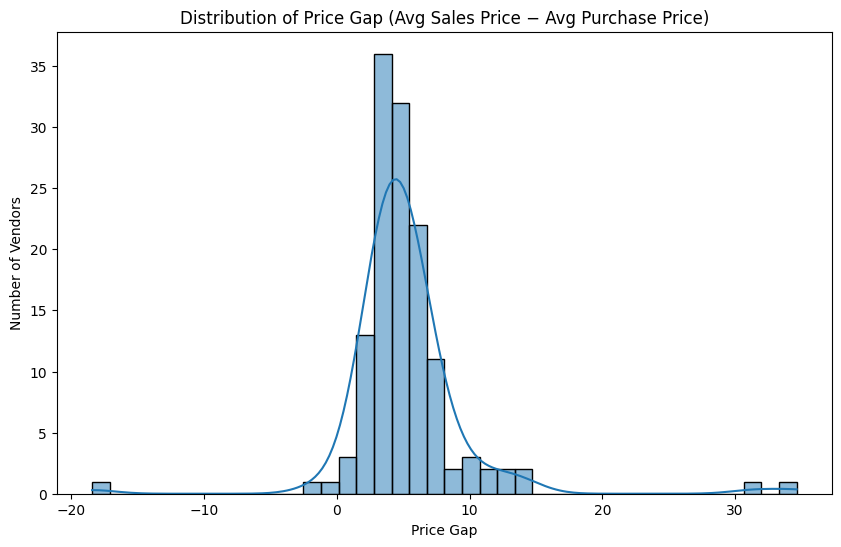

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(vendor_year['PriceGap'], bins=40, kde=True)
plt.title("Distribution of Price Gap (Avg Sales Price − Avg Purchase Price)")
plt.xlabel("Price Gap")
plt.ylabel("Number of Vendors")
plt.show()


# Insight

Most vendors maintain a healthy positive price gap, indicating strong markup and profitable pricing.
A small number of premium brands deliver extremely high price gaps.
Negative gaps exist and suggest discounting, pricing errors, or slow-moving SKUs needing review.

## Top Vendors by Margin %

In [18]:
top_margin = vendor_year.sort_values("MarginPct", ascending=False).head(10)
top_margin


,VendorNumber,VendorName,Year,PurchaseQty,PurchaseDollars,AvgPurchasePrice,SalesQty,SalesDollars,AvgSalesPrice,Profit,MarginPct,PriceGap
246,90034.0,EXCLUSIVE WINES & SPIRITS,2024,0.0,0.00,NaN,2.0,55.98,27.990000,55.98,1.000000,NaN
244,1002.0,BERNIKO LLC,2024,0.0,0.00,NaN,1.0,16.99,16.990000,16.99,1.000000,NaN
245,9710.0,WHYTE & MACKAY,2024,0.0,0.00,NaN,2.0,31.98,15.990000,31.98,1.000000,NaN
85,4425.0,MARTIGNETTI COMPANIES,2024,3136.0,40216.11,12.824015,2578355.0,40992395.93,15.898662,40952179.82,0.999019,3.074648
34,1587.0,VINEYARD BRANDS INC,2024,371.0,10951.51,29.518895,166244.0,1845237.53,11.099574,1834286.02,0.994065,-18.419321
47,2000.0,SOUTHERN WINE & SPIRITS NE,2024,4198.0,40803.92,9.719848,397696.0,5729494.21,14.406718,5688690.29,0.992878,4.686871
243,201359.0,FLAVOR ESSENCE INC,2024,1.0,17.00,17.000000,59.0,1474.41,24.990000,1457.41,0.988470,7.990000
209,90026.0,SILVER MOUNTAIN CIDERS,2024,17.0,77.18,4.540000,52.0,381.48,7.336154,304.30,0.797683,2.796154
29,1439.0,CAPSTONE INTERNATIONAL,2024,4.0,54.64,13.660000,13.0,246.87,18.990000,192.23,0.778669,5.330000
45,1703.0,ALISA CARR BEVERAGES,2024,438.0,34951.68,79.798356,1062.0,118167.38,111.268719,83215.70,0.704219,31.470363


# Insight

High-margin vendors often have:
- Zero or low purchase quantity (free or old stock)
- Small sales quantity where all revenue = profit
- Or extremely profitable product lines (Martignetti, Southern Wine & Spirits)


## Vendors with Lowest or Negative Margins

In [19]:
low_margin = vendor_year.sort_values("MarginPct").head(10)
low_margin


,VendorNumber,VendorName,Year,PurchaseQty,PurchaseDollars,AvgPurchasePrice,SalesQty,SalesDollars,AvgSalesPrice,Profit,MarginPct,PriceGap
84,4425.0,MARTIGNETTI COMPANIES,2024,2488570.0,26195391.20,10.526283,2963.0,54910.37,18.532018,-26140480.83,-476.057270,8.005736
33,1587.0,VINEYARD BRANDS LLC,2024,168904.0,1171792.03,6.937622,104.0,4323.96,41.576538,-1167468.07,-269.999739,34.638917
48,2000.0,SOUTHERN GLAZERS W&S OF NE,2024,395969.0,3631511.13,9.171201,3288.0,40440.12,12.299307,-3591071.01,-88.799712,3.128106
155,9099.0,TRUETT HURST,2024,24.0,236.64,9.860000,1.0,14.99,14.990000,-221.65,-14.786524,5.130000
0,2.0,"IRA GOLDMAN AND WILLIAMS, LLP",2024,328.0,5630.88,17.167317,42.0,1265.58,30.132857,-4365.30,-3.449249,12.965540
112,6280.0,UNCORKED,2024,243.0,2966.31,12.207037,62.0,1124.38,18.135161,-1841.93,-1.638174,5.928124
35,1587.0,VINEYARD BRANDS LLC,2024,371.0,10951.51,29.518895,104.0,4323.96,41.576538,-6627.55,-1.532750,12.057644
233,90059.0,BLACK COVE BEVERAGES,2024,837.0,13174.38,15.740000,313.0,6256.87,19.990000,-6917.51,-1.105586,4.250000
99,5083.0,LOYAL DOG WINERY,2024,216.0,2088.72,9.670000,74.0,1111.26,15.017027,-977.46,-0.879596,5.347027
7,287.0,APPOLO VINEYARDS LLC,2024,230.0,2399.70,10.433478,108.0,1616.92,14.971481,-782.78,-0.484118,4.538003


# Insight

Low-margin vendors consistently show large purchase volumes with weak sell-through, causing negative profit.
These patterns indicate overstocking, poor demand planning, or slow-moving products.
These vendors require immediate review for pricing, promotion, or inventory reduction.

## Vendor Segmentation (Profit vs Volume Scatter Plot)

## Choose Segmentation Thresholds

In [20]:
profit_threshold = vendor_year['Profit'].median()
volume_threshold = vendor_year['SalesQty'].median()

profit_threshold, volume_threshold


(-35.42, 82.0)

## Proceed to segment classification

In [21]:
def classify_segment(row):
    if row['Profit'] >= profit_threshold and row['SalesQty'] >= volume_threshold:
        return "High Profit • High Volume"
    elif row['Profit'] >= profit_threshold and row['SalesQty'] < volume_threshold:
        return "High Profit • Low Volume"
    elif row['Profit'] < profit_threshold and row['SalesQty'] >= volume_threshold:
        return "Low Profit • High Volume"
    else:
        return "Low Profit • Low Volume"

vendor_year['Segment'] = vendor_year.apply(classify_segment, axis=1)
vendor_year['Segment'].value_counts()


Segment
High Profit • High Volume    116
Low Profit • Low Volume      114
Low Profit • High Volume       9
High Profit • Low Volume       8
Name: count, dtype: int64

# Insight

High Profit • High Volume (116 vendors)
These are the company’s core performers, generating strong sales and solid profit. They represent the majority of commercial value and should remain strategic priorities.

2. Low Profit • Low Volume (114 vendors)
A large long-tail segment with minimal sales and weak profitability. These vendors add little business impact and may require review for SKU cleanup or reduced purchasing.

3. Low Profit • High Volume (9 vendors)
A small but critical risk group. These vendors sell a lot but generate poor profit, indicating pricing issues or cost inefficiencies that need urgent attention.

4. High Profit • Low Volume (8 vendors)
Niche but highly profitable vendors. They offer strong margins despite low sales volume and may be ideal for premium or targeted marketing strategies.

## Vendor Segmentation Scatter Plot (Profit vs Volume)

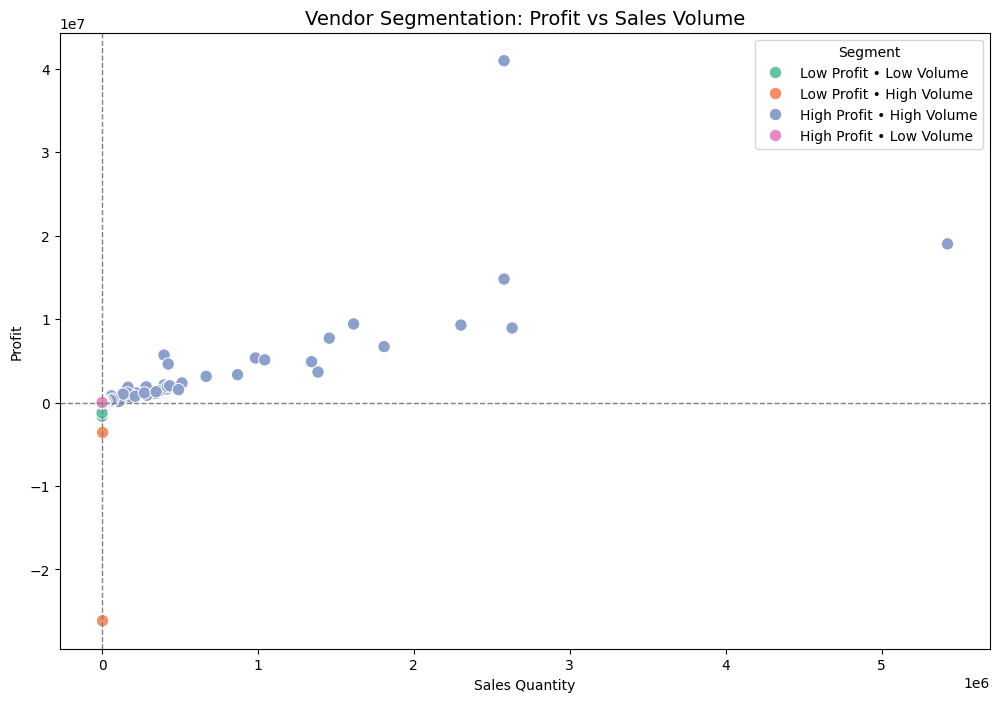

In [22]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=vendor_year,
    x='SalesQty',
    y='Profit',
    hue='Segment',
    palette='Set2',
    s=80
)

# Add quadrant reference lines
plt.axvline(volume_threshold, color='grey', linestyle='--', linewidth=1)
plt.axhline(profit_threshold, color='grey', linestyle='--', linewidth=1)

plt.title("Vendor Segmentation: Profit vs Sales Volume", fontsize=14)
plt.xlabel("Sales Quantity")
plt.ylabel("Profit")
plt.legend(title="Segment")
plt.show()


## Insight

Most vendors fall into the high-profit/high-volume category, driving strong, stable business performance.
2. A small cluster of high-volume vendors with negative profit indicates pricing or cost inefficiencies.
3. Low-volume vendors show mixed profitability, representing both premium niche brands and low-impact long-tail suppliers.

## Bulk Purchasing Impact Analysis
- oes purchasing more units reduce our cost per unit?

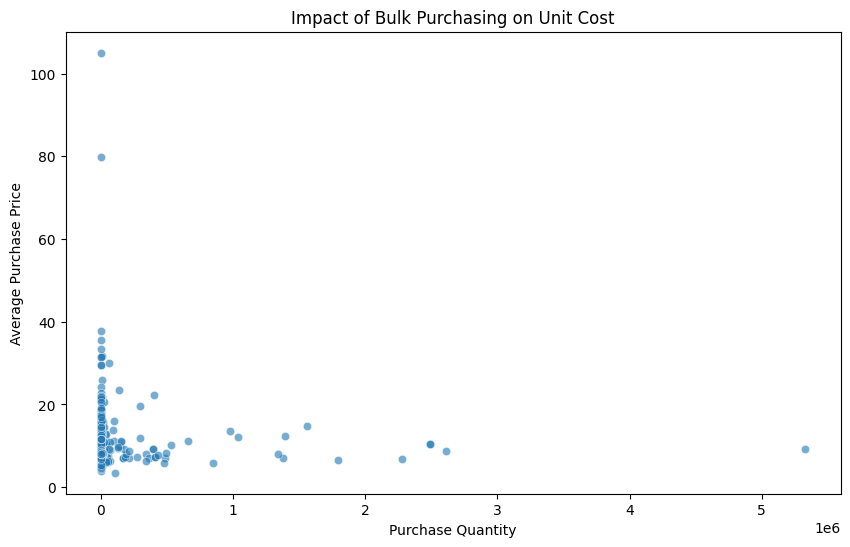

,PurchaseQty,AvgPurchasePrice
PurchaseQty,1.000000,-0.098599
AvgPurchasePrice,-0.098599,1.000000


In [23]:
# Prepare data for bulk purchasing analysis
bulk = vendor_year.copy()

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=bulk,
    x="PurchaseQty",
    y="AvgPurchasePrice",
    alpha=0.6
)

plt.xlabel("Purchase Quantity")
plt.ylabel("Average Purchase Price")
plt.title("Impact of Bulk Purchasing on Unit Cost")

plt.show()

# Correlation
bulk[["PurchaseQty", "AvgPurchasePrice"]].corr()


# Insight

1. There is no strong evidence that higher purchase quantities lead to lower unit prices.
2. Vendor pricing appears flat, regardless of order size, indicating no economies of scale.
3. The company should re-evaluate vendor contracts and negotiate volume-based discounts.

# Inventory Turnover Analysis
- How fast do we sell the stock we purchase?


In [25]:
import pandas as pd

begin_inv = pd.read_csv("../data/begin_inventory.csv")
end_inv = pd.read_csv("../data/end_inventory.csv")
purchases = pd.read_csv("../data/purchases.csv")


In [26]:
begin = begin_inv[['Brand', 'onHand']].groupby('Brand').sum().rename(columns={'onHand':'BeginQty'})
end = end_inv[['Brand', 'onHand']].groupby('Brand').sum().rename(columns={'onHand':'EndQty'})

inventory = begin.merge(end, on='Brand', how='outer')
inventory['AvgInventory'] = (inventory['BeginQty'] + inventory['EndQty']) / 2

inventory.head()


,BeginQty,EndQty,AvgInventory
Brand,,,
58,281.0,385.0,333.0
60,288.0,146.0,217.0
61,12.0,12.0,12.0
62,384.0,459.0,421.5
63,365.0,442.0,403.5


# Merge Inventory with Vendor-Year Table

In [27]:
# Map brand-level inventory to vendor-year
brand_vendor = purchases[['Brand', 'VendorNumber']].drop_duplicates()

inventory_vendor = inventory.merge(brand_vendor, on='Brand', how='left')
inventory_vendor = inventory_vendor.groupby('VendorNumber', as_index=False)['AvgInventory'].sum()


# Merge Inventory into vendor_year

In [28]:
vendor_year = vendor_year.merge(inventory_vendor, on='VendorNumber', how='left')
vendor_year['InventoryTurnover'] = vendor_year['SalesQty'] / vendor_year['AvgInventory']


# Clean Impossible Values

In [29]:
vendor_year['InventoryTurnover'].replace([np.inf, -np.inf], np.nan, inplace=True)
vendor_year['InventoryTurnover'] = vendor_year['InventoryTurnover'].fillna(0)


# Visualize Inventory Turnover Distribution

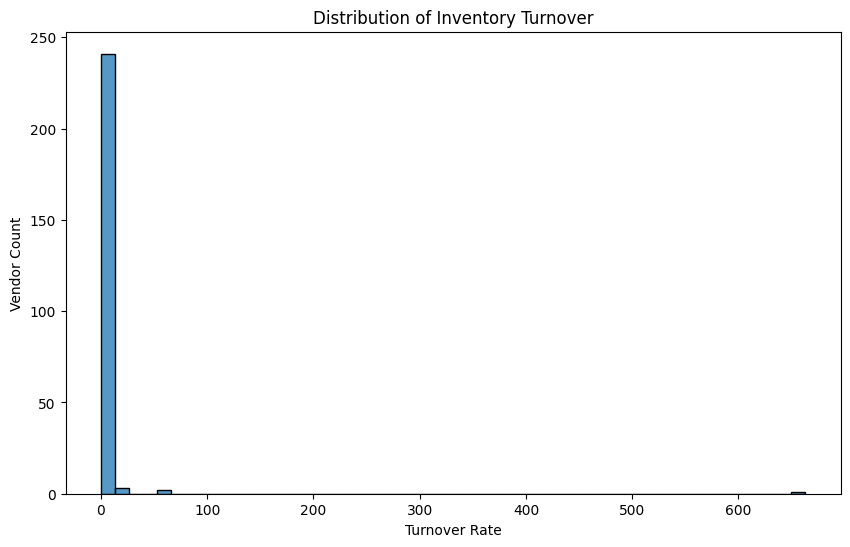

In [30]:
plt.figure(figsize=(10,6))
sns.histplot(vendor_year['InventoryTurnover'], bins=50)
plt.title("Distribution of Inventory Turnover")
plt.xlabel("Turnover Rate")
plt.ylabel("Vendor Count")
plt.show()


# Insight
  Inventory turnover is heavily right-skewed. Most vendors have low turnover rates, pointing to slow-moving stock and excess inventory, while a small group achieves exceptionally high turnover. This indicates mismatch between purchasing decisions and actual sales demand

In [32]:
# Top 10 fastest vendors
vendor_year[['VendorName', 'InventoryTurnover']].sort_values('InventoryTurnover', ascending=False).head(10)



,VendorName,InventoryTurnover
2,ADAMBA IMPORTS INTL INC,663.000000
53,BLACK PRINCE DISTILLERY INC,63.714286
115,OLE SMOKY DISTILLERY LLC,55.585023
101,MANGO BOTTLING INC,23.058773
105,MILTONS DISTRIBUTING CO,22.695652
22,BULLY BOY DISTILLERS,14.508972
16,SAZERAC NORTH AMERICA INC.,11.741359
73,HEAVEN HILL DISTILLERIES,11.486028
25,CALEDONIA SPIRITS INC,11.368254
134,SAZERAC CO INC,11.197449


# Insight

1. Several vendors (e.g., Adamba Imports, Ole Smoky, Black Prince) show exceptionally high turnover, indicating very strong demand.
2. These vendors efficiently convert inventory into sales, reducing holding costs.
3. They are ideal candidates for prioritized restocking and expansion

In [33]:
# Top 10 slowest vendors (non-zero)
vendor_year[vendor_year['InventoryTurnover'] > 0][['VendorName', 'InventoryTurnover']].sort_values('InventoryTurnover').head(10)



,VendorName,InventoryTurnover
33,VINEYARD BRANDS LLC,0.004630
35,VINEYARD BRANDS LLC,0.004630
86,MARTIGNETTI COMPANIES,0.007522
84,MARTIGNETTI COMPANIES,0.007522
48,SOUTHERN GLAZERS W&S OF NE,0.056869
46,SOUTHERN GLAZERS W&S OF NE,0.056869
7,APPOLO VINEYARDS LLC,0.279070
45,ALISA CARR BEVERAGES,0.957619
133,R.P.IMPORTS INC,1.069552
217,CANDIA VINEYARDS,1.136847


# Insight

Many vendors show extremely low turnover, indicating substantial slow-moving inventory.
2. This creates cash-flow pressure and increases holding costs.
3. These vendors require review for SKU reduction, clearance pricing, or reduced purchasing.

In [34]:
# Dead stock vendors
vendor_year[vendor_year['InventoryTurnover'] == 0][['VendorName']].head(10)


,VendorName
1,AAPER ALCOHOL & CHEMICAL CO
3,ADAMBA IMPORTS INTL INC
5,ALTAMAR BRANDS LLC
9,ATLANTIC IMPORTING COMPANY
11,BACARDI USA INC
13,BANFI PRODUCTS CORP
15,STATE WINE & SPIRITS
17,SAZERAC NORTH AMERICA INC.
18,BRONCO WINE COMPANY
19,BRONCO WINE COMPANY


# Insight

Several vendors show zero turnover, indicating unsold stock throughout the year.
2. This ties up working capital and signals misalignment between inventory and customer demand.
3. These vendors are priority candidates for discontinuation or aggressive markdowns.

# Final Vendor Performance Dataset

In [35]:
vendor_year['IsDeadStock'] = vendor_year['InventoryTurnover'] == 0
vendor_year['IsFastMover'] = vendor_year['InventoryTurnover'] >= vendor_year['InventoryTurnover'].quantile(0.95)
vendor_year['IsSlowMover'] = (vendor_year['InventoryTurnover'] > 0) & \
                              (vendor_year['InventoryTurnover'] <= vendor_year['InventoryTurnover'].quantile(0.25))


In [36]:
final_cols = [
    'VendorNumber', 'VendorName', 'Year',
    'PurchaseQty', 'SalesQty',
    'PurchaseDollars', 'SalesDollars',
    'AvgPurchasePrice', 'AvgSalesPrice', 'PriceGap',
    'Profit', 'MarginPct',
    'AvgInventory', 'InventoryTurnover',
    'Segment', 'IsDeadStock', 'IsFastMover', 'IsSlowMover'
]

vendor_final = vendor_year[final_cols].copy()
vendor_final.head()


,VendorNumber,VendorName,Year,PurchaseQty,SalesQty,PurchaseDollars,SalesDollars,AvgPurchasePrice,AvgSalesPrice,PriceGap,Profit,MarginPct,AvgInventory,InventoryTurnover,Segment,IsDeadStock,IsFastMover,IsSlowMover
0,2.0,"IRA GOLDMAN AND WILLIAMS, LLP",2024,328.0,42.0,5630.88,1265.58,17.167317,30.132857,12.965540,-4365.30,-3.449249,11.0,3.818182,Low Profit • Low Volume,False,False,False
1,54.0,AAPER ALCOHOL & CHEMICAL CO,2024,1.0,0.0,105.07,0.00,105.070000,NaN,NaN,-105.07,NaN,0.0,0.000000,Low Profit • Low Volume,True,False,False
2,60.0,ADAMBA IMPORTS INTL INC,2024,4429.0,3978.0,71840.44,67576.22,16.220465,16.987486,0.767021,-4264.22,-0.063102,6.0,663.000000,Low Profit • High Volume,False,True,False
3,60.0,ADAMBA IMPORTS INTL INC,2025,303.0,0.0,4929.81,0.00,16.270000,NaN,NaN,-4929.81,NaN,6.0,0.000000,Low Profit • Low Volume,True,False,False
4,105.0,ALTAMAR BRANDS LLC,2024,314.0,325.0,11138.18,15748.75,35.471911,48.457692,12.985781,4610.57,0.292758,141.5,2.296820,High Profit • High Volume,False,False,False


In [38]:
vendor_final.to_csv("../data_processed/vendor_performance.csv", index=False)


In [39]:
vendor_final.head()


,VendorNumber,VendorName,Year,PurchaseQty,SalesQty,PurchaseDollars,SalesDollars,AvgPurchasePrice,AvgSalesPrice,PriceGap,Profit,MarginPct,AvgInventory,InventoryTurnover,Segment,IsDeadStock,IsFastMover,IsSlowMover
0,2.0,"IRA GOLDMAN AND WILLIAMS, LLP",2024,328.0,42.0,5630.88,1265.58,17.167317,30.132857,12.965540,-4365.30,-3.449249,11.0,3.818182,Low Profit • Low Volume,False,False,False
1,54.0,AAPER ALCOHOL & CHEMICAL CO,2024,1.0,0.0,105.07,0.00,105.070000,NaN,NaN,-105.07,NaN,0.0,0.000000,Low Profit • Low Volume,True,False,False
2,60.0,ADAMBA IMPORTS INTL INC,2024,4429.0,3978.0,71840.44,67576.22,16.220465,16.987486,0.767021,-4264.22,-0.063102,6.0,663.000000,Low Profit • High Volume,False,True,False
3,60.0,ADAMBA IMPORTS INTL INC,2025,303.0,0.0,4929.81,0.00,16.270000,NaN,NaN,-4929.81,NaN,6.0,0.000000,Low Profit • Low Volume,True,False,False
4,105.0,ALTAMAR BRANDS LLC,2024,314.0,325.0,11138.18,15748.75,35.471911,48.457692,12.985781,4610.57,0.292758,141.5,2.296820,High Profit • High Volume,False,False,False
